# Basin demos

Low-resolution basin / settling-time fields for four model and task pairs, over a 2-D slice through each model's latent initial condition space. 
Weights (and, for EqR, the pinned upstream source) download on first use.
 
Requires `torch`, `matplotlib`, `numpy`, and `scipy`. Raise `RES` for sharper fields.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from loopscape import get_solver
from loopscape.utils import batched_apply
from loopscape.metrics import basin_entropy, uncertainty_exponent

RES = 15                      # linear resolution -> RES**2 initial conditions

if torch.backends.mps.is_available():
    DEV = "mps"
elif torch.cuda.is_available():
    DEV = "cuda"
else:
    DEV = "cpu"


MAZE = "############################### #               #   #     ### # ############# # # # # # ###   #     #     # # #   # # ### ##### # # ### # # ##### #####       #   #   #       #   ############### ##### ##### # ###   #     #   #   # #   # # ### # # ### # ### # ### # ### ### # # #   # #   #   # #     ### # # # ### # ##### # ##### ### # # # #   #  S  # #     # ### # # # ######### # ### # ##### #   #           #   # #   ### ### ############### ##### ### #   #   #         # #     ### # ### # ####### ### # # ##### # #   #       #       # # ### ### ######### ########### ###   # #       #   #         ### # # ####### ### # ########### # #   #     #   #   #     ##### ### # ##### ##### # ### ###   #   # #     #   #   # # ### # # ### # ##### # ##### # ### # # #   #     # # #   #   ### ### # # ##### # # # # # #####       #     #   #   #G    ##############################################################"
SUDOKU = ".....6.....7.3.4..5..8.....9.8.7.3...1.....9...498.7....2....4387....2......2...."

def mesh(res):
    g = torch.linspace(-1, 1, res)
    x, y = torch.meshgrid(g, g, indexing="xy")
    return torch.stack([x.ravel(), y.ravel()], -1)


def plane(shape, seed=0):
    """Random orthonormal 2-plane through the full latent space."""
    torch.manual_seed(seed)
    Q, _ = torch.linalg.qr(torch.randn(int(np.prod(shape)), 2))
    return Q[:, 0].reshape(shape), Q[:, 1].reshape(shape)


def to_traces(result):
    # [steps][B] decoded grids -> (B, steps, H, W) int8
    return torch.swapaxes(torch.tensor(np.asarray(result.intermediates), dtype=torch.int8), 0, 1)

def convergence_times(traces):
    conv = (traces == traces[:, -1:]).all(-1).all(-1)
    return conv.shape[1] - conv.sum(1)


## EqR on Sudoku


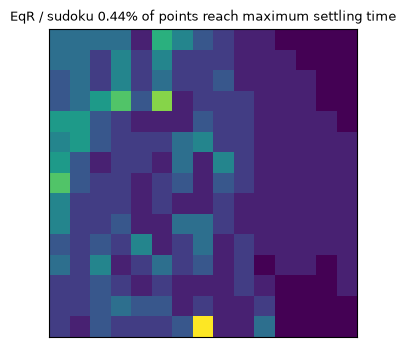

In [ ]:
solver = get_solver("eqr", device=DEV)
u, v = plane((97, 512))

def f(p):
    z = p[:, 0, None, None] * u + p[:, 1, None, None] * v
    r = solver.solve_batch(SUDOKU, z_H=z, z_L=z * 0, max_steps=24,
                           noise_scale=0.0, return_intermediates=True)
    return to_traces(r)

traces = batched_apply(f, mesh(RES), batch_size=128, pad_dim=1)
convergence_times_image = convergence_times(traces).reshape(RES, RES)
plt.imshow(convergence_times_image)
print("Uncertainy Exponent: ", uncertainty_exponent(convergence_times_image, box_size=5)["uncertainty_exponent"])
print("Basin Entropy: ", basin_entropy(convergence_times_image, box_size=5)["basin_entropy"])

## EqR on Maze

Uncertainy Exponent:  0.11114525250276713
Basin Entropy:  1.3033898210984058


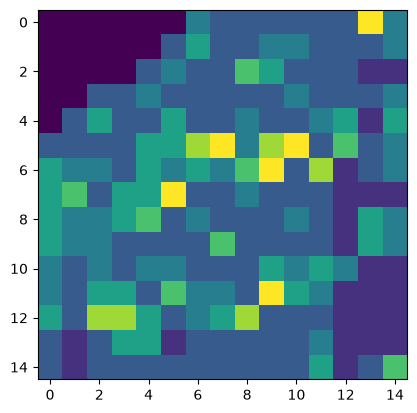

In [15]:
solver = get_solver("eqr", task="maze", device=DEV)
u, v = plane((916, 128))

def f(p):
    z = 10 * (p[:, 0, None, None] * u + p[:, 1, None, None] * v)
    r = solver.solve_batch(MAZE, z_H=z, z_L=z * 0, max_steps=24,
                           noise_scale=0.0, return_intermediates=True)
    return to_traces(r)

traces = batched_apply(f, mesh(RES), batch_size=128, pad_dim=1)
convergence_times_image = convergence_times(traces).reshape(RES, RES)
plt.imshow(convergence_times_image)
print("Uncertainy Exponent: ", uncertainty_exponent(convergence_times_image, box_size=5)["uncertainty_exponent"])
print("Basin Entropy: ", basin_entropy(convergence_times_image, box_size=5)["basin_entropy"])

## FPRM on Sudoku


In [6]:
SUDOKU = "..4.6...16..3...8.....24.....9..2..4.5.......4...3.26.....8...........172....384."          # Sudoku-Extreme, rating 125 (sweep sample: seed 0, index 2)


Uncertainy Exponent:  -0.005067799013894137
Basin Entropy:  3.02240884019078


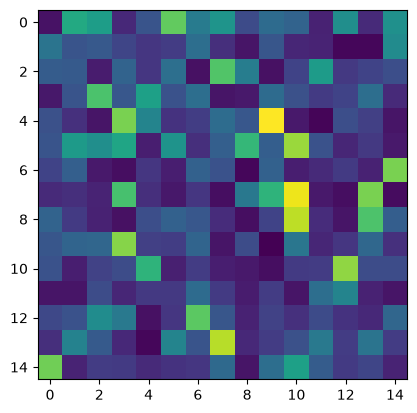

In [12]:
solver = get_solver("fprm", device=DEV)
u, v = plane((97, 512))
torch.manual_seed(0)
z0 = torch.randn(97, 512)

def f(p):
    z = p[:, 0, None, None] * u + p[:, 1, None, None] * v + z0
    z = 500 * z / z.square().mean(-1, keepdim=True).add(1e-5).sqrt()
    r = solver.solve_batch(SUDOKU, initial_latents=z, fp_thresh=0.02,
                           max_iters=200, return_intermediates=True)
    return to_traces(r)

traces = batched_apply(f, mesh(RES), batch_size=128, pad_dim=1)
convergence_times_image = convergence_times(traces).reshape(RES, RES)
plt.imshow(convergence_times_image)
print("Uncertainy Exponent: ", uncertainty_exponent(convergence_times_image, box_size=5)["uncertainty_exponent"])
print("Basin Entropy: ", basin_entropy(convergence_times_image, box_size=5)["basin_entropy"])

## FPRM on Maze

In [29]:
MAZE = "###############################S    #     #           #   ####### # # # ### ##### ### # ###   # # # #   # #   # #   # ### ### ### ### # # # ### ### ### #   #   # # #   #   # #   ### # ### ### # # ##### # # ##### #   # #     #     #   #   ### ### # # ######### ####### ### #   # # #   #       #     ### # ### # # # # ####### ### ### #     #   # # #   #   #   ### ########### # # # # ######### #     #     #   # #       ### # ### # ######### ####### ### # # #   #       # #   #   ### # # ##### # ##### # # # ##### #     #   #   #   # # #   ### ##### # ##### # ### # ### ###       #     #   #   # #   ### ########### ##### ##### #####       #           #   #   ######### ########### # # ### ###     #         #   # #   # ### ### ######### ### # ### # ###   # #       #   # # # # # ### # ### ### ##### ### # # # ### #       #           #    G##############################################################"    # generated perfect maze, rating 141 (sweep sample: seed 0, index 0)


Uncertainy Exponent:  0.040294512304562304
Basin Entropy:  2.6409342276913756


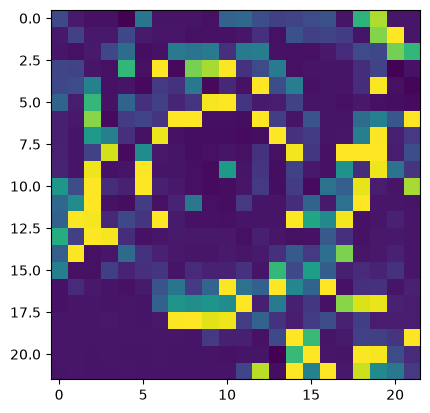

In [30]:
from loopscape import fractal

RES_FM = 11*2   # heavier model; keep the demo grid smaller
solver = get_solver("fprm", task="maze", device=DEV)
base, u, v = fractal.plane_basis(seed=0)
pts = fractal.grid(center=(0.1, 0.1), width=1.0, res=RES_FM)

def f(p):
    z = fractal.points_to_latents(base, u, v, p, radius=0.3)
    r = solver.solve_batch(MAZE, initial_latents=z, fp_thresh=0.1,
                           max_iters=200, stepsize=1.0, return_intermediates=True)
    return to_traces(r)

traces = batched_apply(f, pts, batch_size=64, pad_dim=1)
convergence_times_image = convergence_times(traces).reshape(RES_FM, RES_FM)
plt.imshow(convergence_times_image)
print("Uncertainy Exponent: ", uncertainty_exponent(convergence_times_image, box_size=5)["uncertainty_exponent"])
print("Basin Entropy: ", basin_entropy(convergence_times_image, box_size=5)["basin_entropy"])

## Parcae / Countdown
A 140M Parcae SFT'd on Countdown with a reduced integration step (`dt_scale = 0.3`), probed
on the initial recurrent state: plane orthogonal to the baseline `h_bar`, extent 2000x the
natural state norm, settle time = loops until the answer token stops changing. Weights download from
[GilpinLab/parcae-countdown-v1](https://huggingface.co/GilpinLab/parcae-countdown-v1)
on first use (or set `LOOPSCAPE_PARCAE_CD_SRC` to a local run dir).

([], [])

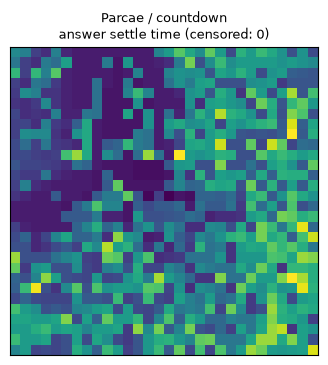

In [3]:
from loopscape.parcae import countdown as cd

RES_CD, M = 15*2, 70 # Resolution and max settle time for countdown basin demo
basin = cd.CountdownBasin.load(device=DEV)
basin.prelude(cd.build_prompt([1, 14, 20, 57, 77], 28))   # gold: 14*(1+(20+57)/77)

h_bar = basin.baseline(seed=2)
u, v = cd.context_plane_basis(h_bar, seed=2)
ext = 2000.0 * basin.natural_norm()
g = np.linspace(-ext, ext, RES_CD)
a, b = np.meshgrid(g, g, indexing="xy")
toks = basin.trace_answers(cd.build_h0(h_bar, a.ravel(), b.ravel(), u, v), M=M)
settle = cd.settle_time_batch(toks).reshape(RES_CD, RES_CD)

plt.figure(figsize=(4, 4))
plt.imshow(settle, origin="lower")
plt.title(f"Parcae / countdown\nanswer settle time (censored: {(settle >= M).sum()})", fontsize=9)
plt.xticks([]); plt.yticks([])